# Teacher's baseline

### Check speechbrain library

In [12]:
import sys
print("Interpreter:", sys.executable)

try:
    import speechbrain
    print("SpeechBrain imported. Version:", speechbrain.__version__)
    from speechbrain.inference.classifiers import EncoderClassifier
    print("EncoderClassifier from inference available")
except Exception as e:
    print("Error:", type(e).__name__, e)

Interpreter: C:\Users\Svetozar\PycharmProjects\ASTRA_voiceprint\.venv\Scripts\python.exe
SpeechBrain imported. Version: 1.1.1
EncoderClassifier from inference available


### Disable display of warnings

In [13]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*weights_only=False.*")

### Establishing the teacher's baseline

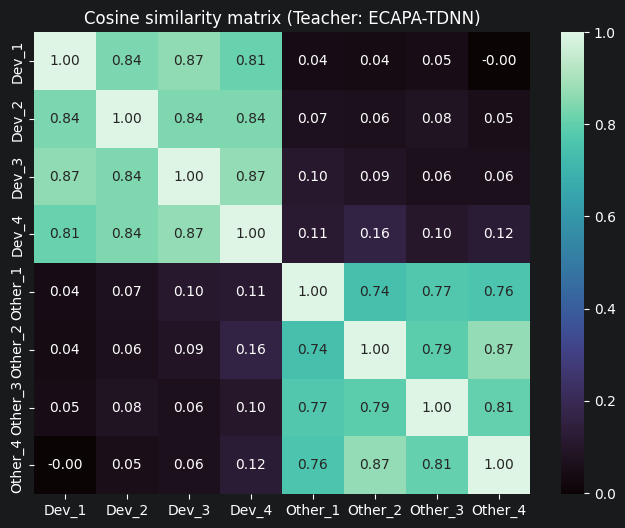

In [14]:
import os
import sys

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

# Clearing the frozen speechbrain modules from the kernel memory
for mod in list(sys.modules.keys()):
    if "speechbrain" in mod:
        del sys.modules[mod]

import torch
import torchaudio
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from speechbrain.inference.classifiers import EncoderClassifier
from speechbrain.utils.fetching import LocalStrategy

dev_dir = os.path.abspath("data/raw/developer")
dist_dir = os.path.abspath("data/raw/distractors")

dev_files = [os.path.join(dev_dir, f) for f in os.listdir(dev_dir) if f.lower().endswith(".wav")]
dist_files = [os.path.join(dist_dir, f) for f in os.listdir(dist_dir) if f.lower().endswith(".wav")]

device = "cuda:0" if torch.cuda.is_available() else "cpu"

classifier = EncoderClassifier.from_hparams(
    source="models/teacher/ecapa_voxceleb",
    savedir="models/teacher/ecapa_voxceleb",
    run_opts={"device": device},
    local_strategy=LocalStrategy.COPY
)

def get_embedding(wav_path):
    signal, fs = torchaudio.load(wav_path)


    if signal.shape[0] > 1:
        signal = torch.mean(signal, dim=0, keepdim=True)


    if fs != 16000:
        signal = torchaudio.transforms.Resample(fs, 16000)(signal)

    with torch.no_grad():
        emb = classifier.encode_batch(signal.to(device))
        emb = torch.nn.functional.normalize(emb, dim=-1).squeeze().flatten().cpu().numpy()

    return emb

all_files = dev_files + dist_files
labels = [f"Dev_{i+1}" for i in range(len(dev_files))] + [f"Other_{i+1}" for i in range(len(dist_files))]

embeddings = [get_embedding(f) for f in all_files]

matrix = np.zeros((len(all_files), len(all_files)))
for i in range(len(all_files)):
    for j in range(len(all_files)):
        matrix[i, j] = float(np.dot(embeddings[i], embeddings[j]))

plt.figure(figsize=(8, 6))
sns.heatmap(matrix, xticklabels=labels, yticklabels=labels, annot=True, cmap="mako", fmt=".2f")
plt.title("Cosine similarity matrix (Teacher: ECAPA-TDNN)")
plt.show()